# Data Preprocessing and Exploratory Data Analysis
This notebook loads the car dataset, performs data cleaning, feature engineering, and exploratory analysis to prepare it for modeling.

In [64]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [65]:
headers = [
    "car_ID", "symboling", "CarName", "fueltype", "aspiration",
    "doornumber", "carbody", "drivewheel", "enginelocation",
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "enginetype", "cylindernumber", "enginesize", "fuelsystem",
    "boreratio", "stroke", "compressionratio", "horsepower",
    "peakrpm", "citympg", "highwaympg", "price"
]

df = pd.read_csv("car_dataset.data", names=headers, header=None)
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Initial Data Overview

In [66]:
# Basic info about dataset
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nSample records:')
print(df.head())

Shape: (205, 26)

Data types:
car_ID                int64
symboling            object
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio            object
stroke               object
compressionratio    float64
horsepower           object
peakrpm              object
citympg               int64
highwaympg            int64
price                object
dtype: object

Sample records:
   car_ID symboling      CarName fueltype aspiration doornumber      carbody  \
0       3         ?  alfa-romero      gas        std        two  convertible   
1       3         ?  alfa-romero      gas        st

In [67]:
# Statistical summary of numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheelbase,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
carlength,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
carwidth,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
carheight,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curbweight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
enginesize,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compressionratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
citympg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highwaympg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


In [68]:
# Replace '?' with NaN and convert numeric columns to numeric types
missing_values = {'?': np.nan}
df.replace(missing_values, inplace=True)

numeric_columns = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
    'enginesize', 'boreratio', 'stroke', 'compressionratio',
    'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Missing values by column:')
print(df.isnull().sum())

Missing values by column:
car_ID               0
symboling           41
CarName              0
fueltype             0
aspiration           0
doornumber           2
carbody              0
drivewheel           0
enginelocation       0
wheelbase            0
carlength            0
carwidth             0
carheight            0
curbweight           0
enginetype           0
cylindernumber       0
enginesize           0
fuelsystem           0
boreratio            4
stroke               4
compressionratio     0
horsepower           2
peakrpm              2
citympg              0
highwaympg           0
price                4
dtype: int64


In [69]:
# Split the CarName column to create CompanyName and normalize spelling variations
df['CompanyName'] = (
    df['CarName'].str.split().str[0]
    .str.lower()
)

replacements = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}

df['CompanyName'] = df['CompanyName'].replace(replacements)
df.drop(columns=['CarName'], inplace=True)

df['CompanyName'].value_counts().head(15)

CompanyName
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
Name: count, dtype: int64

In [70]:
# Standardize object columns to lowercase and inspect categories
string_columns = df.select_dtypes(include='object').columns
for col in string_columns:
    df[col] = df[col].str.lower()

print('Category counts:')
print(df[string_columns].nunique())
print('\nDuplicate rows:', df.duplicated().sum())

Category counts:
symboling         51
fueltype           2
aspiration         2
doornumber         2
carbody            5
drivewheel         3
enginelocation     2
enginetype         7
cylindernumber     7
fuelsystem         8
CompanyName       22
dtype: int64

Duplicate rows: 0


In [71]:
# Remove duplicate rows if any and fill missing values

df = df.drop_duplicates()
for col in numeric_columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in string_columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
car_ID              0
symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
CompanyName         0
dtype: int64


C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\1143252686.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\1143252686.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [72]:
# Convert categorical variables to category dtype where appropriate
categorical_cols = [
    'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
    'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'CompanyName'
]
for col in categorical_cols:
    df[col] = df[col].astype('category')

print(df[categorical_cols].dtypes)

fueltype          category
aspiration        category
doornumber        category
carbody           category
drivewheel        category
enginelocation    category
enginetype        category
cylindernumber    category
fuelsystem        category
CompanyName       category
dtype: object


In [73]:
# Review cleaned dataset schema and statistics
print(df.info())
print('\nNumeric summary:')
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   car_ID            205 non-null    int64   
 1   symboling         205 non-null    object  
 2   fueltype          205 non-null    category
 3   aspiration        205 non-null    category
 4   doornumber        205 non-null    category
 5   carbody           205 non-null    category
 6   drivewheel        205 non-null    category
 7   enginelocation    205 non-null    category
 8   wheelbase         205 non-null    float64 
 9   carlength         205 non-null    float64 
 10  carwidth          205 non-null    float64 
 11  carheight         205 non-null    float64 
 12  curbweight        205 non-null    int64   
 13  enginetype        205 non-null    category
 14  cylindernumber    205 non-null    category
 15  enginesize        205 non-null    int64   
 16  fuelsystem        205 non-

In [74]:
# Final cleaned columns and shape
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

Shape: (205, 26)

Columns:
['car_ID', 'symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'CompanyName']


###  Visualizing the data

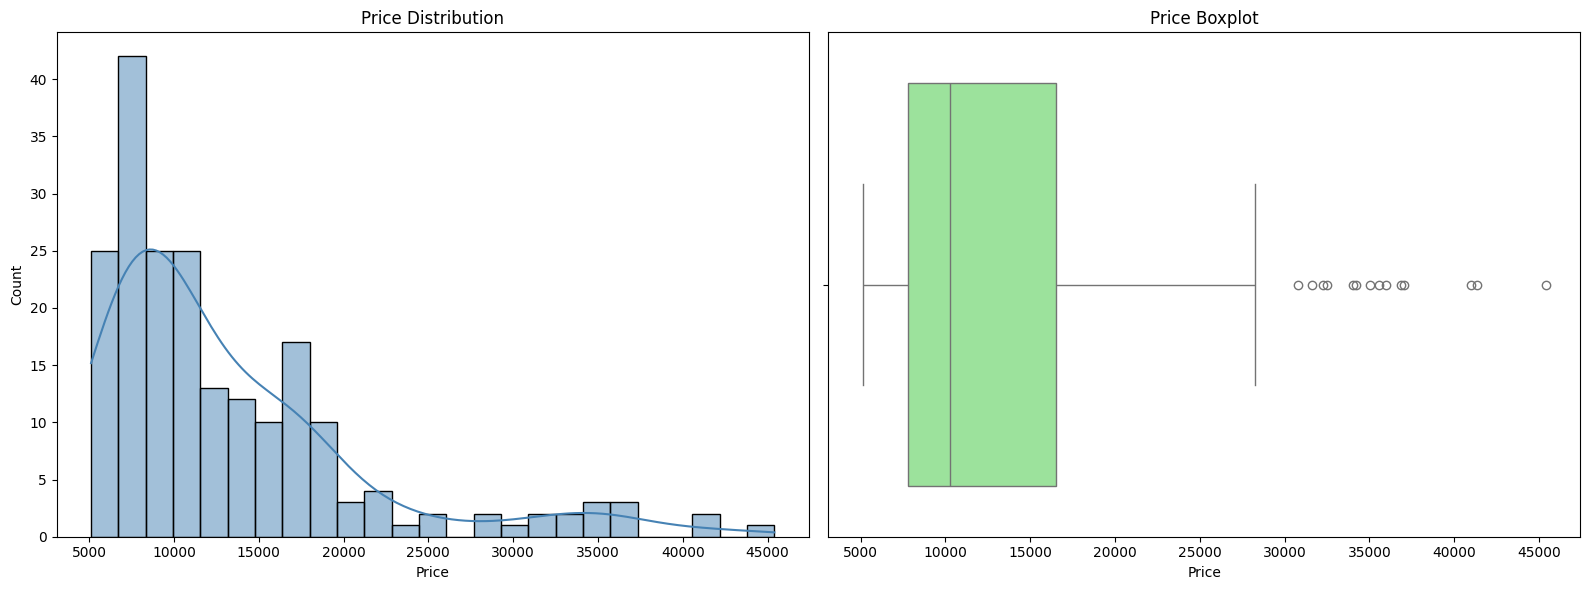

In [75]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='steelblue', bins=25)
plt.title('Price Distribution')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='lightgreen')
plt.title('Price Boxplot')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\3882830389.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_company = df.groupby('CompanyName')['price'].median().sort_values(ascending=False).head(12)
C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\3882830389.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_by_company.values, y=price_by_company.index, palette='magma')


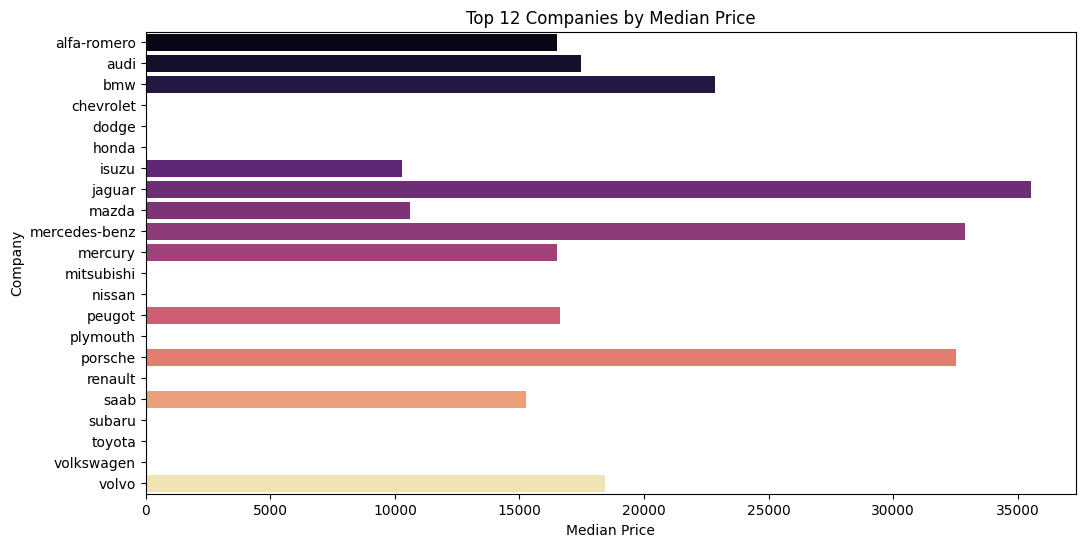

In [76]:
# Identify top companies by median price
price_by_company = df.groupby('CompanyName')['price'].median().sort_values(ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(x=price_by_company.values, y=price_by_company.index, palette='magma')
plt.title('Top 12 Companies by Median Price')
plt.xlabel('Median Price')
plt.ylabel('Company')
plt.show()

C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\472058935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fueltype', data=df, palette='pastel')
C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\472058935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='carbody', y='price', data=df, palette='pastel')
C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\472058935.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='aspiration', y='price', data=df, palette='pastel')


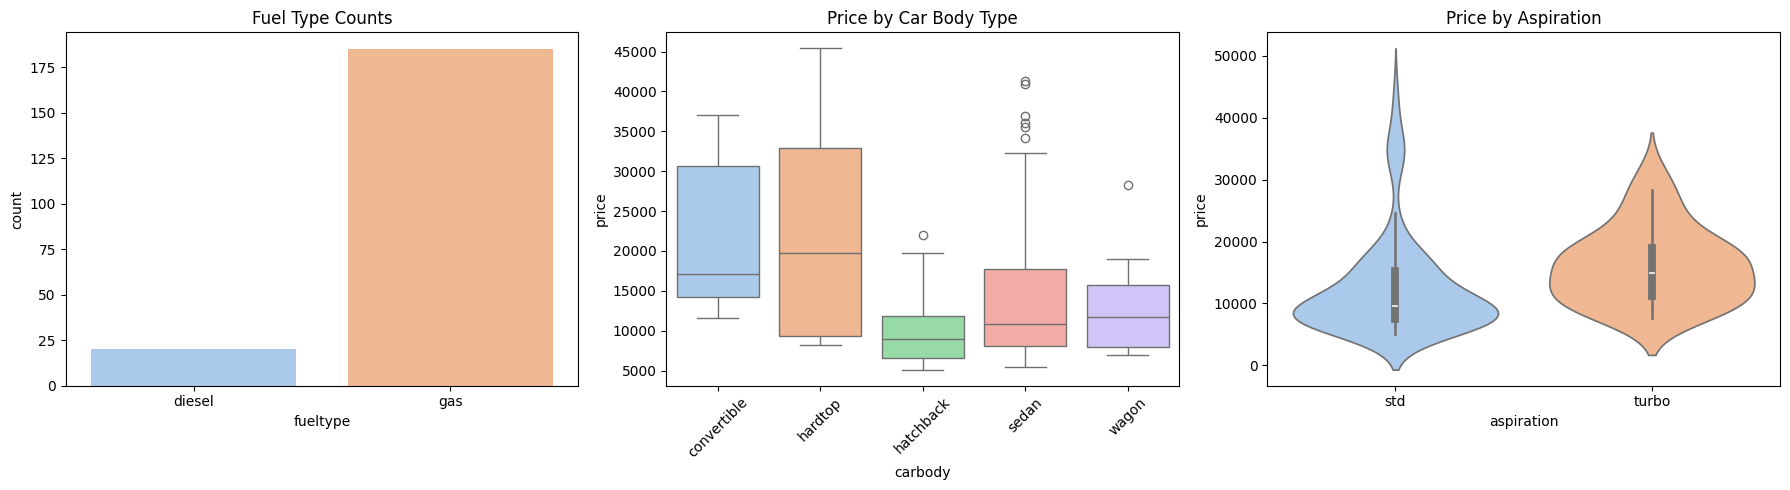

In [77]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='fueltype', data=df, palette='pastel')
plt.title('Fuel Type Counts')

plt.subplot(1, 3, 2)
sns.boxplot(x='carbody', y='price', data=df, palette='pastel')
plt.title('Price by Car Body Type')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.violinplot(x='aspiration', y='price', data=df, palette='pastel')
plt.title('Price by Aspiration')

plt.tight_layout()
plt.show()

C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\856012290.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='symboling', data=df, palette='cubehelix')
C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_18600\856012290.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='symboling', y='price', data=df, palette='cubehelix')


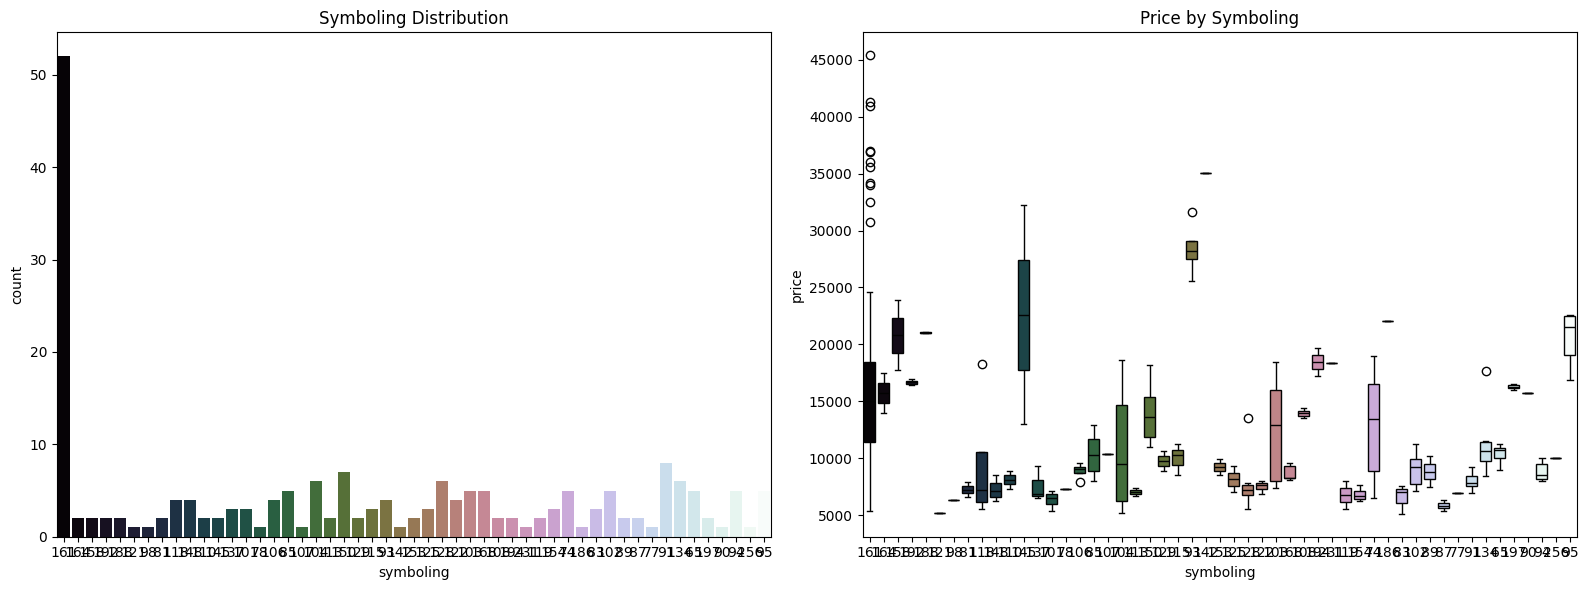

In [78]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='symboling', data=df, palette='cubehelix')
plt.title('Symboling Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='symboling', y='price', data=df, palette='cubehelix')
plt.title('Price by Symboling')

plt.tight_layout()
plt.show()

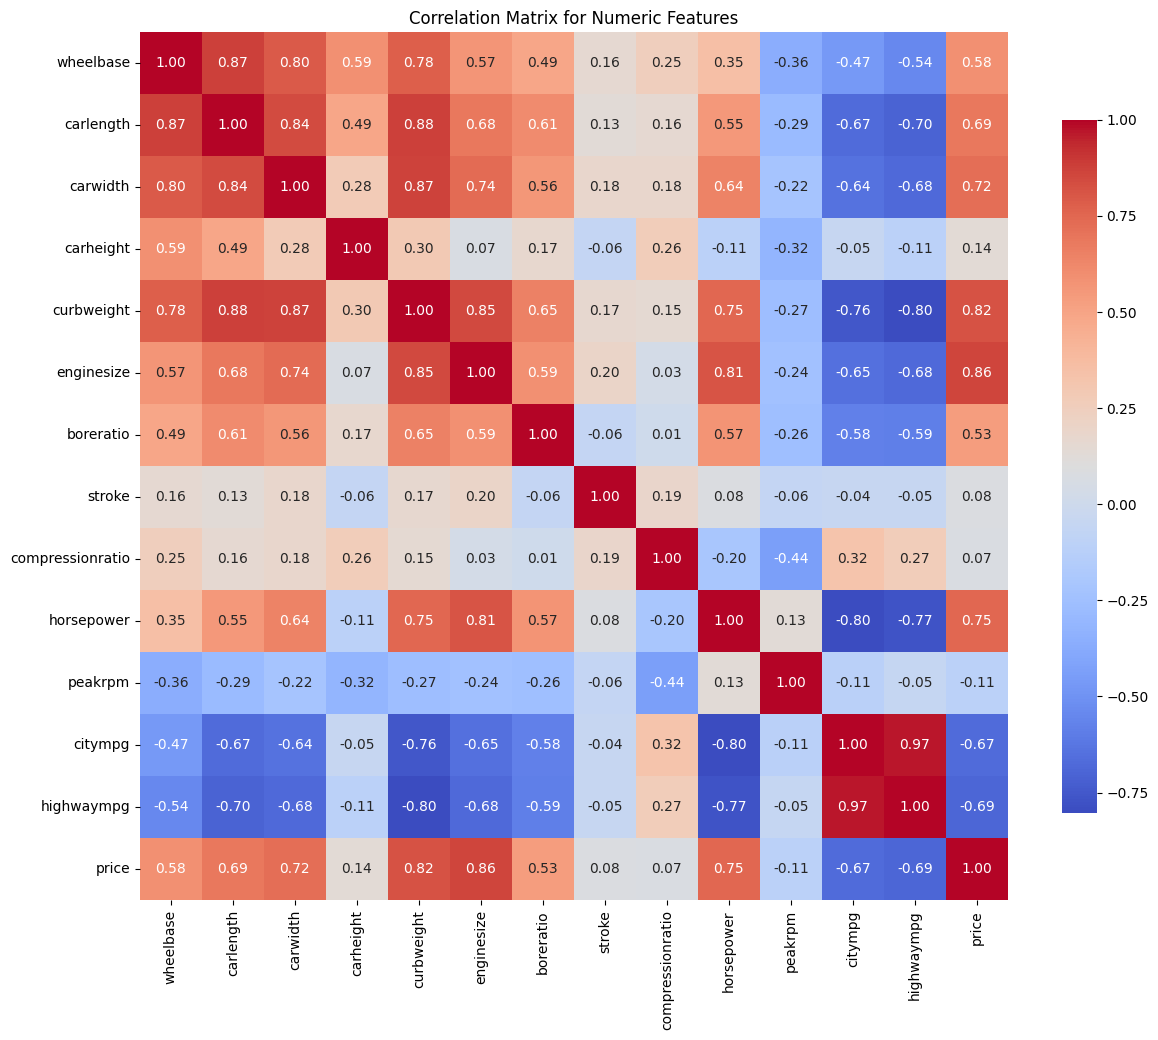

Correlation with price:
price               1.000000
enginesize          0.860343
curbweight          0.819817
horsepower          0.749919
carwidth            0.724558
carlength           0.686567
wheelbase           0.584847
boreratio           0.532861
carheight           0.140439
stroke              0.083627
compressionratio    0.072890
peakrpm            -0.107283
citympg            -0.668822
highwaympg         -0.693037
Name: price, dtype: float64


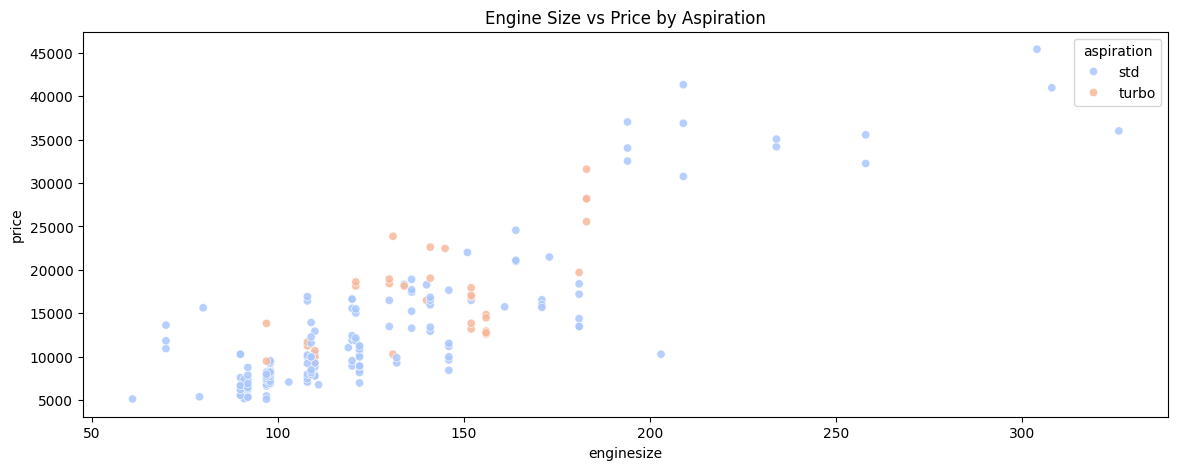

In [79]:
plt.figure(figsize=(14, 12))

numeric_for_corr = df[numeric_columns]
correlation = numeric_for_corr.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.75})
plt.title('Correlation Matrix for Numeric Features')
plt.show()

price_corr = correlation['price'].sort_values(ascending=False)
print('Correlation with price:')
print(price_corr)

plt.figure(figsize=(14, 5))
sns.scatterplot(x='enginesize', y='price', data=df, hue='aspiration', palette='coolwarm', alpha=0.85)
plt.title('Engine Size vs Price by Aspiration')
plt.show()